## Aim 

In this code, the Land Surface Temperature data (LST) using band 10 at the ward level are merged with the road characteristics but only the drivable roads.

In [1]:
from pathlib import Path

## import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import linregress, pearsonr
from sklearn.linear_model import LinearRegression

## Reading in the data

In [2]:
# Define the paths
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = BASE_DIR / "images"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


### Land Surface Temperature

In [3]:
lst_path = PROCESSED_DIR /'lstband10summer_bang.csv'
print(lst_path)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstband10summer_bang.csv


In [4]:
df_lst_mean_summer = pd.read_csv(lst_path)

In [5]:
df_lst_mean_summer.head()

,system:index,ward_name,mean,ward_id
0,0,25 - Vinayaka Layout,39.324657,25
1,1,2 - Aerocity,38.621582,2
2,2,3 - Chowdeshwari ward,38.597490,3
3,3,15 - Ramamurthy Nagara,38.432678,15
4,4,58 - Nagashettyhalli,37.427218,58


In [6]:
print(f"The minimum temperature is {df_lst_mean_summer['mean'].min()}.")
print(f"The maximum temperature is {df_lst_mean_summer['mean'].max()}.")

The minimum temperature is 35.593766695678646.
The maximum temperature is 42.37974275787706.


### Road density

In [7]:
road_density_path = PROCESSED_DIR /'results_bangalore_all_roads_drive.csv'
df_road_density = pd.read_csv(road_density_path)

In [8]:
df_road_density.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,street_length,street_density,area
0,0,25,25 - Vinayaka Layout,West,67483.275675,26205.033174,2.575203e+06
1,1,2,2 - Aerocity,North,55739.693648,5433.217381,1.025906e+07
2,2,3,3 - Chowdeshwari ward,North,59321.900312,9225.355507,6.430310e+06
3,3,15,15 - Ramamurthy Nagara,East,21795.255226,27164.887476,8.023319e+05
4,4,58,58 - Nagashettyhalli,North,22246.721886,23284.035489,9.554496e+05


In [9]:
merged = pd.merge(df_lst_mean_summer, df_road_density, on='ward_name')
merged.head()

,system:index,ward_name,mean,ward_id_x,Unnamed: 0,ward_id_y,Corporatio,street_length,street_density,area
0,0,25 - Vinayaka Layout,39.324657,25,0,25,West,67483.275675,26205.033174,2.575203e+06
1,1,2 - Aerocity,38.621582,2,1,2,North,55739.693648,5433.217381,1.025906e+07
2,2,3 - Chowdeshwari ward,38.597490,3,2,3,North,59321.900312,9225.355507,6.430310e+06
3,3,15 - Ramamurthy Nagara,38.432678,15,3,15,East,21795.255226,27164.887476,8.023319e+05
4,4,58 - Nagashettyhalli,37.427218,58,4,58,North,22246.721886,23284.035489,9.554496e+05


Only retain the relevant variables and rename:

In [10]:
merged = merged[['ward_name', 'mean', 'ward_id_x', 'Corporatio', 'street_length', 'street_density', 'area']]
merged.head()

,ward_name,mean,ward_id_x,Corporatio,street_length,street_density,area
0,25 - Vinayaka Layout,39.324657,25,West,67483.275675,26205.033174,2.575203e+06
1,2 - Aerocity,38.621582,2,North,55739.693648,5433.217381,1.025906e+07
2,3 - Chowdeshwari ward,38.597490,3,North,59321.900312,9225.355507,6.430310e+06
3,15 - Ramamurthy Nagara,38.432678,15,East,21795.255226,27164.887476,8.023319e+05
4,58 - Nagashettyhalli,37.427218,58,North,22246.721886,23284.035489,9.554496e+05


In [11]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio': 'Corporation',
    'mean': 'mean_lst'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area
0,25 - Vinayaka Layout,39.324657,25,West,67483.275675,26205.033174,2.575203e+06
1,2 - Aerocity,38.621582,2,North,55739.693648,5433.217381,1.025906e+07
2,3 - Chowdeshwari ward,38.597490,3,North,59321.900312,9225.355507,6.430310e+06
3,15 - Ramamurthy Nagara,38.432678,15,East,21795.255226,27164.887476,8.023319e+05
4,58 - Nagashettyhalli,37.427218,58,North,22246.721886,23284.035489,9.554496e+05


In [12]:
print(f'The mininim street density is {merged["street_density"].min()} metres or {merged["street_density"].min()/1000} km per square km.')
print(f'The maximimum street density is {merged["street_density"].max()} metres or {merged["street_density"].max()/1000} km per square km.')

The mininim street density is 2974.0274091464794 metres or 2.9740274091464793 km per square km.
The maximimum street density is 42085.66630016988 metres or 42.08566630016988 km per square km.


In [13]:
# index of min and max street density
idx_min = merged["street_density"].idxmin()
idx_max = merged["street_density"].idxmax()

In [14]:
# ward names
ward_min = merged.loc[idx_min, "ward_name"]
ward_max = merged.loc[idx_max, "ward_name"]

In [15]:
print(f' The ward with the minimum street density is {ward_min} and the maximum street density is {ward_max}.')

 The ward with the minimum street density is 24 - Agaram and the maximum street density is 53 - Rayapuram.


#### Street density

In [16]:
fig_path = IMAGES_DIR / 'regression_bangalore_street_density_drive.png'

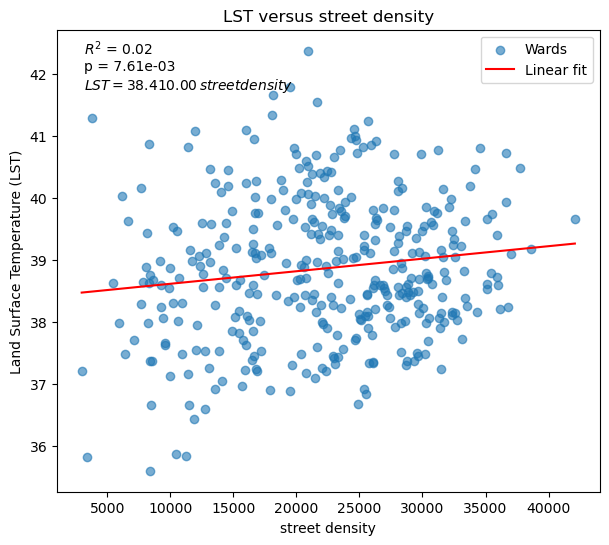

In [17]:
# x and y
x = merged["street_density"]
y = merged["mean_lst"]

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("street density")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus street density")
plt.legend()

# annotation
plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,street density$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


In [18]:
p_value

np.float64(0.007610775400816425)

In [19]:
print(slope, intercept, r_value)

2.0252191721378023e-05 38.41168638447396 0.13873385545038533


In [20]:
pearsonr(merged['street_density'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.13873385545038536), pvalue=np.float64(0.007610775400816376))

In [21]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['street_density']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     7.202
Date:                Sat, 17 Jan 2026   Prob (F-statistic):            0.00761
Time:                        13:57:17   Log-Likelihood:                -572.81
No. Observations:                 369   AIC:                             1150.
Df Residuals:                     367   BIC:                             1157.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             38.4117      0.177    216.

In [22]:
pearsonr(merged['street_density'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.13873385545038536), pvalue=np.float64(0.007610775400816376))

#### Straightness

In [23]:
straightness_path = PROCESSED_DIR /'results_bangalore_straightness_all_roads_drive.csv'
df_straightness = pd.read_csv(straightness_path)

In [24]:
df_straightness.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,straightness
0,0,25,25 - Vinayaka Layout,West,0.736976
1,1,2,2 - Aerocity,North,0.693418
2,2,3,3 - Chowdeshwari ward,North,0.685726
3,3,15,15 - Ramamurthy Nagara,East,0.696362
4,4,58,58 - Nagashettyhalli,North,0.695818


In [25]:
merged = pd.merge(merged, df_straightness, on='ward_name')
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,Unnamed: 0,ward_id_y,Corporatio,straightness
0,25 - Vinayaka Layout,39.324657,25,West,67483.275675,26205.033174,2.575203e+06,0,25,West,0.736976
1,2 - Aerocity,38.621582,2,North,55739.693648,5433.217381,1.025906e+07,1,2,North,0.693418
2,3 - Chowdeshwari ward,38.597490,3,North,59321.900312,9225.355507,6.430310e+06,2,3,North,0.685726
3,15 - Ramamurthy Nagara,38.432678,15,East,21795.255226,27164.887476,8.023319e+05,3,15,East,0.696362
4,58 - Nagashettyhalli,37.427218,58,North,22246.721886,23284.035489,9.554496e+05,4,58,North,0.695818


In [26]:
merged = merged[['ward_name', 'mean_lst', 'ward_id_x', 'Corporation', 'street_length', 'street_density', 'area', 'straightness']]
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness
0,25 - Vinayaka Layout,39.324657,25,West,67483.275675,26205.033174,2.575203e+06,0.736976
1,2 - Aerocity,38.621582,2,North,55739.693648,5433.217381,1.025906e+07,0.693418
2,3 - Chowdeshwari ward,38.597490,3,North,59321.900312,9225.355507,6.430310e+06,0.685726
3,15 - Ramamurthy Nagara,38.432678,15,East,21795.255226,27164.887476,8.023319e+05,0.696362
4,58 - Nagashettyhalli,37.427218,58,North,22246.721886,23284.035489,9.554496e+05,0.695818


In [27]:
# x and y
x = merged["straightness"]
y = merged["mean_lst"]

In [28]:
fig_path = IMAGES_DIR / 'regression_bangalore_straightness_drive.png'

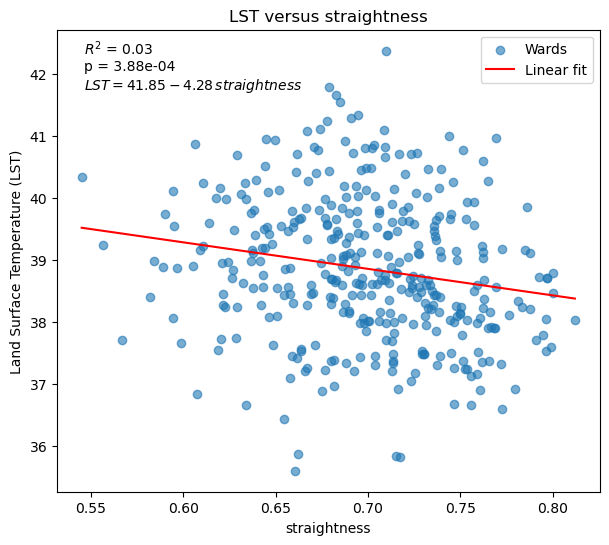

In [29]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("straightness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus straightness")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,straightness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [30]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['straightness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     12.82
Date:                Sat, 17 Jan 2026   Prob (F-statistic):           0.000388
Time:                        13:57:27   Log-Likelihood:                -570.06
No. Observations:                 369   AIC:                             1144.
Df Residuals:                     367   BIC:                             1152.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           41.8544      0.838     49.922   

In [31]:
pearsonr(merged['straightness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.18375202841515698), pvalue=np.float64(0.0003881058219290015))

#### Global closeness

In [32]:
global_closeness_path = PROCESSED_DIR /'results_bangalore_global_closeness_all_roads_drive.csv'
df_global_closeness = pd.read_csv(global_closeness_path)

In [33]:
df_global_closeness.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,closeness
0,0,25,25 - Vinayaka Layout,West,0.000795
1,1,2,2 - Aerocity,North,0.000428
2,2,3,3 - Chowdeshwari ward,North,0.000434
3,3,15,15 - Ramamurthy Nagara,East,0.001345
4,4,58,58 - Nagashettyhalli,North,0.001439


In [34]:
merged = pd.merge(merged, df_global_closeness, on='ward_name')
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,Unnamed: 0,ward_id,Corporatio,closeness
0,25 - Vinayaka Layout,39.324657,25,West,67483.275675,26205.033174,2.575203e+06,0.736976,0,25,West,0.000795
1,2 - Aerocity,38.621582,2,North,55739.693648,5433.217381,1.025906e+07,0.693418,1,2,North,0.000428
2,3 - Chowdeshwari ward,38.597490,3,North,59321.900312,9225.355507,6.430310e+06,0.685726,2,3,North,0.000434
3,15 - Ramamurthy Nagara,38.432678,15,East,21795.255226,27164.887476,8.023319e+05,0.696362,3,15,East,0.001345
4,58 - Nagashettyhalli,37.427218,58,North,22246.721886,23284.035489,9.554496e+05,0.695818,4,58,North,0.001439


In [35]:
merged = merged[['ward_name', 'mean_lst', 'ward_id_x', 'Corporation', 'street_length', 'street_density', 'area', 'straightness', 'closeness']]
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,closeness
0,25 - Vinayaka Layout,39.324657,25,West,67483.275675,26205.033174,2.575203e+06,0.736976,0.000795
1,2 - Aerocity,38.621582,2,North,55739.693648,5433.217381,1.025906e+07,0.693418,0.000428
2,3 - Chowdeshwari ward,38.597490,3,North,59321.900312,9225.355507,6.430310e+06,0.685726,0.000434
3,15 - Ramamurthy Nagara,38.432678,15,East,21795.255226,27164.887476,8.023319e+05,0.696362,0.001345
4,58 - Nagashettyhalli,37.427218,58,North,22246.721886,23284.035489,9.554496e+05,0.695818,0.001439


In [36]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    'closeness': 'global_closeness'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area,straightness,global_closeness
0,25 - Vinayaka Layout,39.324657,25,West,67483.275675,26205.033174,2.575203e+06,0.736976,0.000795
1,2 - Aerocity,38.621582,2,North,55739.693648,5433.217381,1.025906e+07,0.693418,0.000428
2,3 - Chowdeshwari ward,38.597490,3,North,59321.900312,9225.355507,6.430310e+06,0.685726,0.000434
3,15 - Ramamurthy Nagara,38.432678,15,East,21795.255226,27164.887476,8.023319e+05,0.696362,0.001345
4,58 - Nagashettyhalli,37.427218,58,North,22246.721886,23284.035489,9.554496e+05,0.695818,0.001439


In [37]:
# x and y
x = merged["global_closeness"]
y = merged["mean_lst"]

In [38]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [39]:
fig_path = IMAGES_DIR / 'regression_bangalore_global_closeness_drive.png'

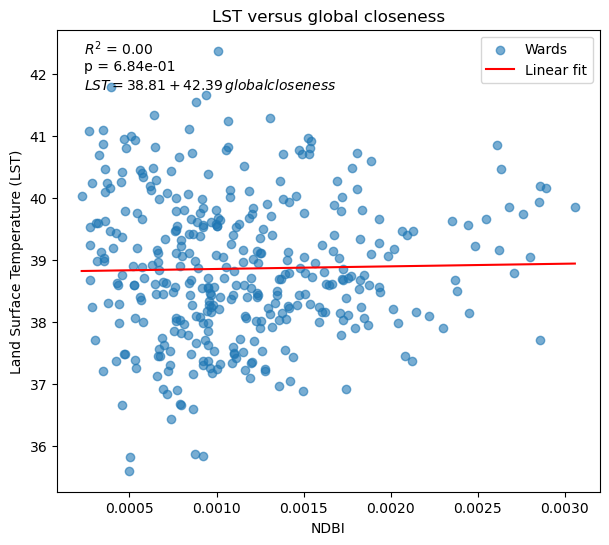

In [40]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("NDBI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus global closeness")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,global closeness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [41]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['global_closeness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.1655
Date:                Sat, 17 Jan 2026   Prob (F-statistic):              0.684
Time:                        13:57:56   Log-Likelihood:                -576.32
No. Observations:                 369   AIC:                             1157.
Df Residuals:                     367   BIC:                             1164.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               38.8111      0.133  

In [42]:
pearsonr(merged['global_closeness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.02123110413946044), pvalue=np.float64(0.6843765062406463))

#### Local closeness

In [43]:
local_closeness_path = PROCESSED_DIR /'results_bangalore_local_closeness_all_roads_drive.csv'
df_local_closeness = pd.read_csv(local_closeness_path)
df_local_closeness.head()

,Unnamed: 0,ward_id,ward_name,Corporatio,closeness_local
0,0,25,25 - Vinayaka Layout,West,0.000362
1,1,2,2 - Aerocity,North,0.000296
2,2,3,3 - Chowdeshwari ward,North,0.000305
3,3,15,15 - Ramamurthy Nagara,East,0.000917
4,4,58,58 - Nagashettyhalli,North,0.000914


In [44]:
merged = pd.merge(merged, df_local_closeness, on='ward_name')
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,global_closeness,Unnamed: 0,ward_id_y,Corporatio,closeness_local
0,25 - Vinayaka Layout,39.324657,25,West,67483.275675,26205.033174,2.575203e+06,0.736976,0.000795,0,25,West,0.000362
1,2 - Aerocity,38.621582,2,North,55739.693648,5433.217381,1.025906e+07,0.693418,0.000428,1,2,North,0.000296
2,3 - Chowdeshwari ward,38.597490,3,North,59321.900312,9225.355507,6.430310e+06,0.685726,0.000434,2,3,North,0.000305
3,15 - Ramamurthy Nagara,38.432678,15,East,21795.255226,27164.887476,8.023319e+05,0.696362,0.001345,3,15,East,0.000917
4,58 - Nagashettyhalli,37.427218,58,North,22246.721886,23284.035489,9.554496e+05,0.695818,0.001439,4,58,North,0.000914


In [45]:
merged = merged[['ward_name', 'mean_lst', 'ward_id_x', 'Corporation', 'street_length', 'street_density', 'area', 'straightness', 'global_closeness', 'closeness_local']]
merged.head()

,ward_name,mean_lst,ward_id_x,Corporation,street_length,street_density,area,straightness,global_closeness,closeness_local
0,25 - Vinayaka Layout,39.324657,25,West,67483.275675,26205.033174,2.575203e+06,0.736976,0.000795,0.000362
1,2 - Aerocity,38.621582,2,North,55739.693648,5433.217381,1.025906e+07,0.693418,0.000428,0.000296
2,3 - Chowdeshwari ward,38.597490,3,North,59321.900312,9225.355507,6.430310e+06,0.685726,0.000434,0.000305
3,15 - Ramamurthy Nagara,38.432678,15,East,21795.255226,27164.887476,8.023319e+05,0.696362,0.001345,0.000917
4,58 - Nagashettyhalli,37.427218,58,North,22246.721886,23284.035489,9.554496e+05,0.695818,0.001439,0.000914


In [46]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    #'closeness': 'global closeness',
    'closeness_local': 'local_closeness'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area,straightness,global_closeness,local_closeness
0,25 - Vinayaka Layout,39.324657,25,West,67483.275675,26205.033174,2.575203e+06,0.736976,0.000795,0.000362
1,2 - Aerocity,38.621582,2,North,55739.693648,5433.217381,1.025906e+07,0.693418,0.000428,0.000296
2,3 - Chowdeshwari ward,38.597490,3,North,59321.900312,9225.355507,6.430310e+06,0.685726,0.000434,0.000305
3,15 - Ramamurthy Nagara,38.432678,15,East,21795.255226,27164.887476,8.023319e+05,0.696362,0.001345,0.000917
4,58 - Nagashettyhalli,37.427218,58,North,22246.721886,23284.035489,9.554496e+05,0.695818,0.001439,0.000914


In [47]:
# x and y
x = merged["local_closeness"]
y = merged["mean_lst"]

In [48]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [49]:
fig_path = IMAGES_DIR / 'regression_bangalore_local_closeness_drive.png'

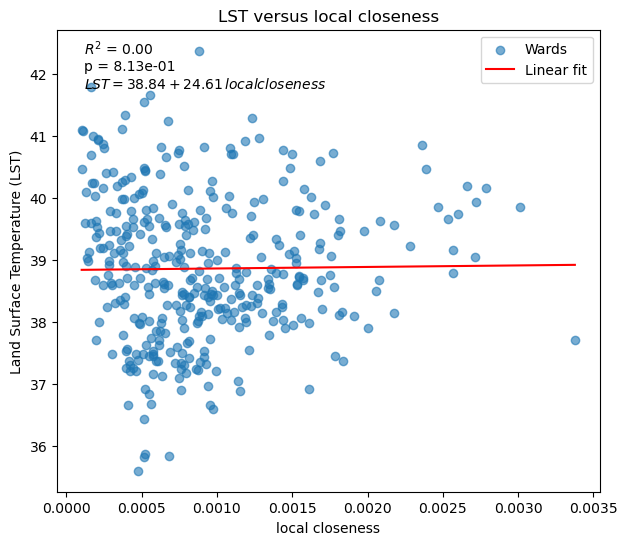

In [50]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("local closeness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus local closeness")
plt.legend()


# annotation


plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,local closeness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [51]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['local_closeness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                   0.05630
Date:                Sat, 17 Jan 2026   Prob (F-statistic):              0.813
Time:                        13:58:11   Log-Likelihood:                -576.37
No. Observations:                 369   AIC:                             1157.
Df Residuals:                     367   BIC:                             1165.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              38.8369      0.113    3

In [52]:
pearsonr(merged['local_closeness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.012384893395724385), pvalue=np.float64(0.8125730420165704))

In [53]:
merged

,ward_name,mean_lst,ward_id,Corporation,street_length,street_density,area,straightness,global_closeness,local_closeness
0,25 - Vinayaka Layout,39.324657,25,West,67483.275675,26205.033174,2.575203e+06,0.736976,0.000795,0.000362
1,2 - Aerocity,38.621582,2,North,55739.693648,5433.217381,1.025906e+07,0.693418,0.000428,0.000296
2,3 - Chowdeshwari ward,38.597490,3,North,59321.900312,9225.355507,6.430310e+06,0.685726,0.000434,0.000305
3,15 - Ramamurthy Nagara,38.432678,15,East,21795.255226,27164.887476,8.023319e+05,0.696362,0.001345,0.000917
4,58 - Nagashettyhalli,37.427218,58,North,22246.721886,23284.035489,9.554496e+05,0.695818,0.001439,0.000914
...,...,...,...,...,...,...,...,...,...,...
364,56 - Gopalpura,39.079316,56,Central,21851.817891,17195.620644,1.270778e+06,0.688229,0.000995,0.000743
365,57 - Cottonpete,40.597494,57,Central,19834.032039,20755.222653,9.556164e+05,0.762392,0.001889,0.001687
366,54 - Binnypete,39.749570,54,Central,10885.028262,22814.336051,4.771135e+05,0.590193,0.001203,0.001645
367,47 - IPD Salappa Ward,39.408972,47,Central,11499.157962,23311.061274,4.932919e+05,0.710204,0.001320,0.001554


## Correlation

In [54]:
vars_df = merged[[
    "mean_lst",
    "street_density",
    "straightness",
    "global_closeness",
    "local_closeness"
]].dropna()

In [55]:
corr = vars_df.corr(method="pearson")

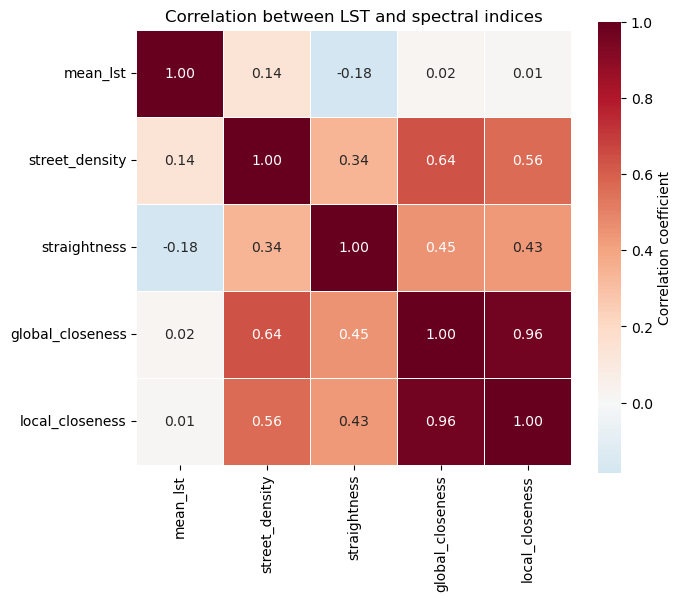

In [56]:
corr_path_indices = IMAGES_DIR / 'corr_indices_bangalore_drive.png'
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation between LST and spectral indices")
plt.tight_layout()
plt.savefig(corr_path_indices, dpi=300, bbox_inches="tight")
plt.show()